## 0 IMPORTS

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import os
from glob import glob
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.dates as mdates


# os.chdir("....") # replace

os.chdir("/Users/christianleis/Library/CloudStorage/OneDrive-Personal/Desktop-OneDrive/02_TU_Wien/Project/reddit_inflation_index")

## 1 Dataset

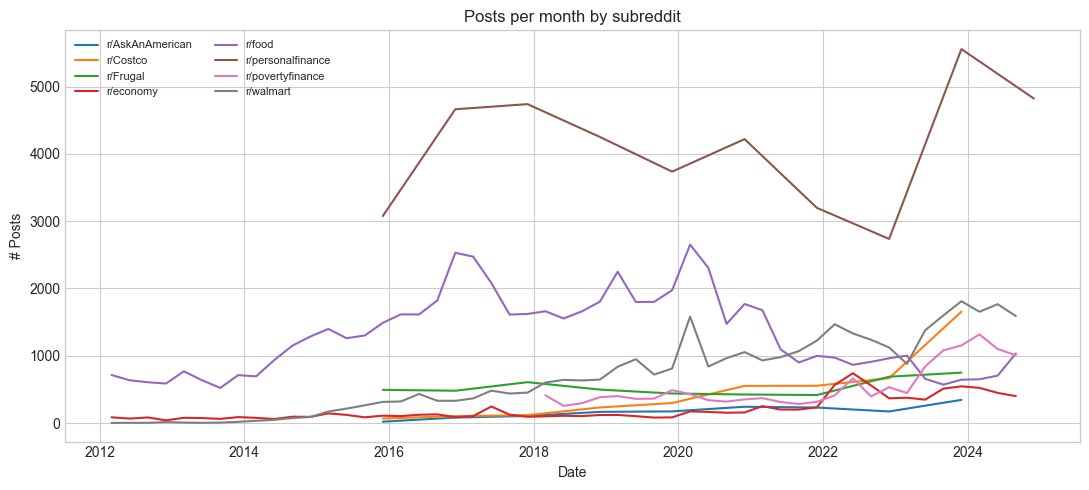

In [ ]:
# %% Imports
import os, re, pathlib
import pandas as pd
import matplotlib.pyplot as plt

BASE = pathlib.Path("data/raw")
FIG_DIR = pathlib.Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

date_re = re.compile(r"(\d{4}-\d{2}-\d{2})\.jsonl$")

def count_lines(path):
    # Count lines in a file (number of posts)
    n = 0
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for _ in f:
            n += 1
    return n

records = []

# Scan directories and files
for subdir in sorted(p for p in BASE.iterdir() if p.is_dir()):
    subreddit = subdir.name
    for f in sorted(subdir.glob("*.jsonl")):
        m = date_re.search(f.name)
        if not m:
            continue
        date = pd.to_datetime(m.group(1), errors="coerce")
        if pd.isna(date):
            continue
        n_posts = count_lines(f)
        records.append({"subreddit": subreddit, "date": date, "n_posts": n_posts})

# Build dataframe
df = pd.DataFrame(records)
if df.empty:
    raise SystemExit("Keine Daten gefunden. Prüfe Pfade/Namen.")
df = df.sort_values(["subreddit", "date"]).reset_index(drop=True)

# Aggreation
df_monthly = (
    df.assign(month=df["date"].values.astype("datetime64[M]"))
      .groupby(["subreddit", "month"], as_index=False)["n_posts"].sum()
      .rename(columns={"month": "date"})
)

# Gesamtzeitreihe (über alle Subreddits)
df_total = (
    df_monthly.groupby("date", as_index=False)["n_posts"].sum()
              .rename(columns={"n_posts": "n_posts_total"})
)

# Save CSVs
out_csv = pathlib.Path("data/analytics")
out_csv.mkdir(parents=True, exist_ok=True)
df_monthly.to_csv(out_csv / "post_counts_per_subreddit.csv", index=False)
df_total.to_csv(out_csv / "post_counts_total.csv", index=False)


# Plot
plt.figure(figsize=(11, 5))
for sub in df_monthly["subreddit"].unique():
    d = df_monthly[df_monthly["subreddit"] == sub]
    plt.plot(d["date"], d["n_posts"], label=f"r/{sub}")
plt.title("Posts per month by subreddit")
plt.xlabel("Date"); plt.ylabel("# Posts")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "posts_timeseries_all_subreddits.png", dpi=200)
plt.show()

## 2.1 VADER DEV

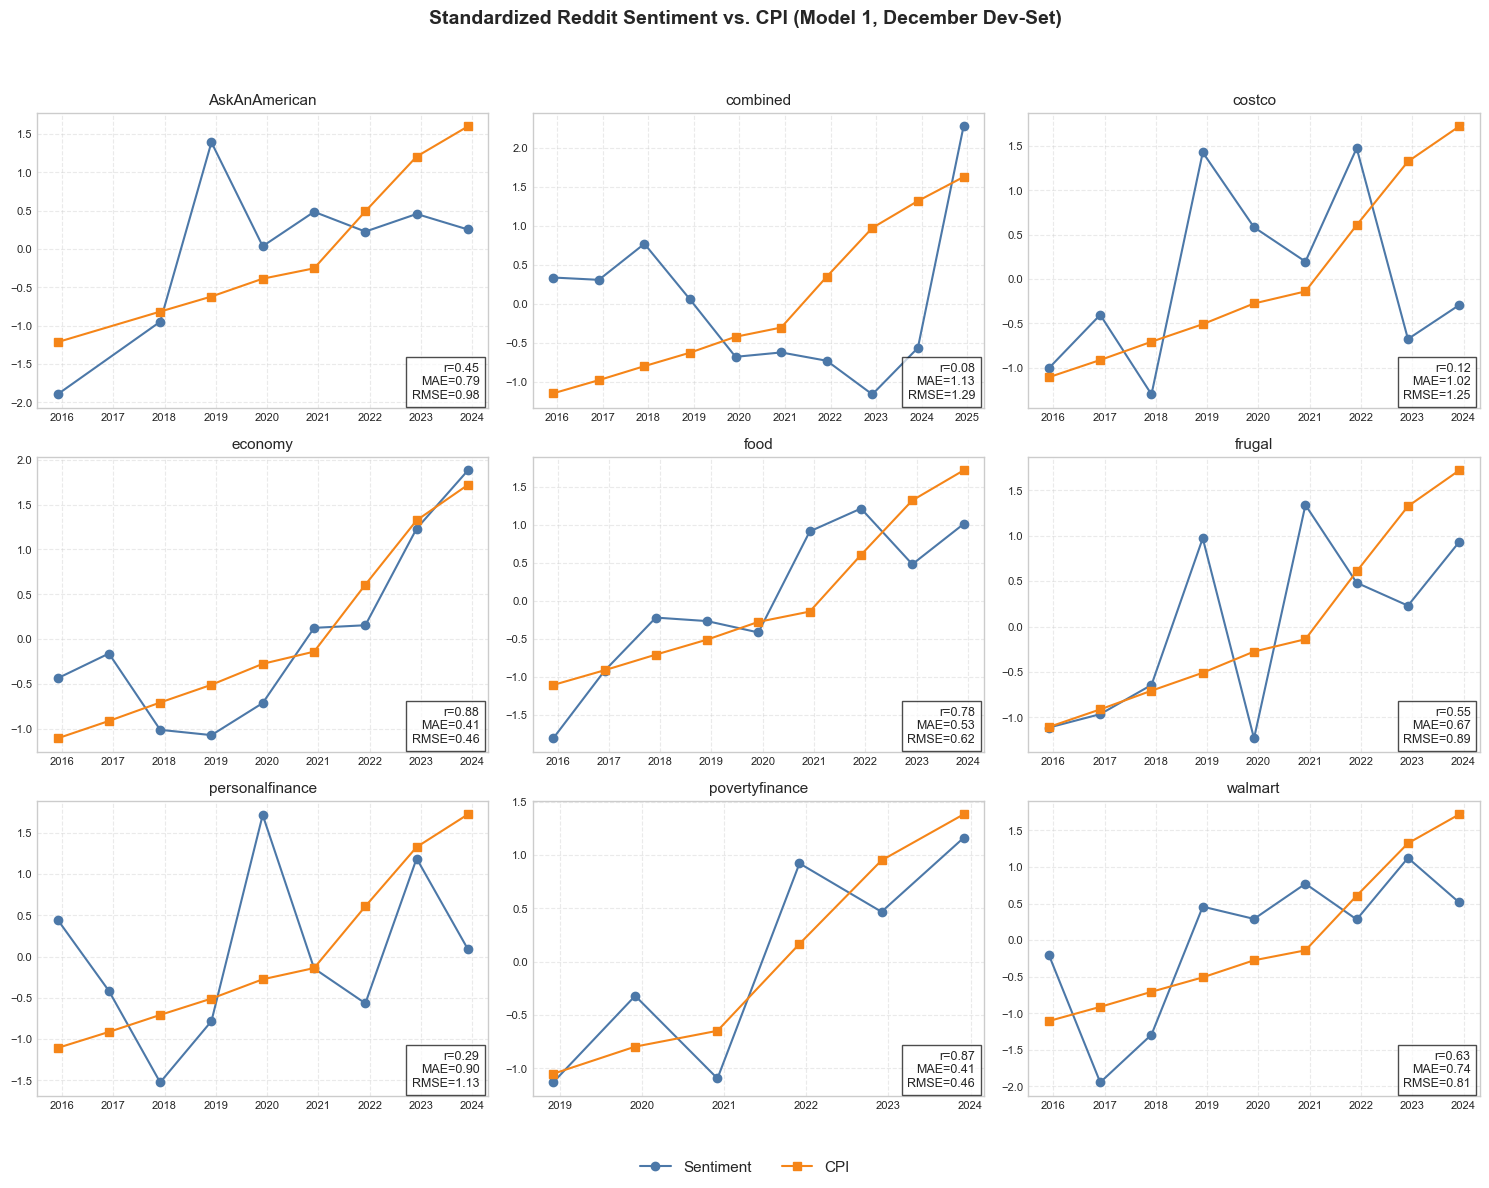

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")

sentiment_color = "#4C78A8" 
cpi_color = "#F58518"

cpi = pd.read_csv("data/inflation/usa_inflation.csv", parse_dates=["date"])
cpi_dec = cpi[cpi["date"].dt.month == 12]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Iterate over sentiment files
for i, file in enumerate(sorted(glob("data/output/model_1_vader/dev_set/vader_dev_*.csv"))):
    name = os.path.basename(file).replace("vader_dev_", "").replace(".csv", "")

    sentiment = pd.read_csv(file, parse_dates=["date"])
    df = pd.merge(sentiment, cpi_dec, on="date", how="inner")

    df["sentiment_z"] = (df["avg_sentiment"] - df["avg_sentiment"].mean()) / df["avg_sentiment"].std()
    df["cpi_z"] = (df["cpi_value"] - df["cpi_value"].mean()) / df["cpi_value"].std()

    # Correlation
    r, _ = pearsonr(df["sentiment_z"], df["cpi_z"])

    if r < 0:
        df["sentiment_z"] = -df["sentiment_z"]
        r, _ = pearsonr(df["sentiment_z"], df["cpi_z"])

    mae = mean_absolute_error(df["cpi_z"], df["sentiment_z"])
    rmse = np.sqrt(mean_squared_error(df["cpi_z"], df["sentiment_z"]))

    ax = axes[i]
    ax.plot(df["date"], df["sentiment_z"], label="Sentiment", color=sentiment_color, marker="o", linewidth=1.5)
    ax.plot(df["date"], df["cpi_z"], label="CPI", color=cpi_color, marker="s", linewidth=1.5)
    ax.set_title(name, fontsize=11)
    ax.text(0.98, 0.02, f"r={r:.2f}\nMAE={mae:.2f}\nRMSE={rmse:.2f}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=9, bbox=dict(facecolor="white", alpha=0.7))
    ax.tick_params(labelsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=11)
fig.suptitle("Standardized Reddit Sentiment vs. CPI (Model 1, December Dev-Set)", fontsize=14, weight="bold")
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

## 2.2 Correlations with subreddit size

,subreddit,r,mae,rmse,size_m
0,AskAnAmerican,0.450270,0.848173,1.048551,1.10
1,costco,0.122660,1.086403,1.324644,1.30
2,economy,0.879743,0.435758,0.490422,1.00
3,food,0.780739,0.565307,0.662210,24.40
4,frugal,0.553601,0.712869,0.944880,6.60
5,personalfinance,0.285969,0.952303,1.195015,21.20
6,povertyfinance,0.871617,0.449399,0.506720,2.30
7,walmart,0.630022,0.789879,0.860207,0.35


Pearson(size_m, MAE) = 0.016  (p=0.97)
Pearson(size_m, r) = -0.041  (p=0.922)


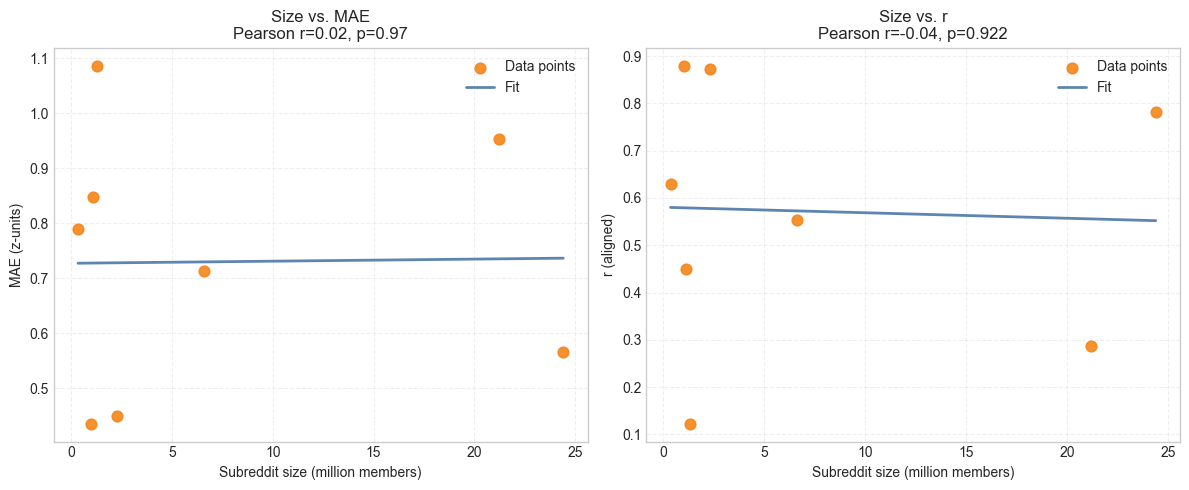

In [11]:
CPI_CSV = "data/inflation/usa_inflation.csv"
VADER_DEV_GLOB = "data/output/model_1_vader/dev_set/vader_dev_*.csv"

cpi = pd.read_csv(CPI_CSV, parse_dates=["date"])
cpi_dec = cpi[cpi["date"].dt.month == 12].copy()

# subreddit sizes in millions (as of 2024)
size_m = {
    "food": 24.4,
    "personalfinance": 21.2,
    "frugal": 6.6,
    "economy": 1.0,
    "povertyfinance": 2.3,
    "costco": 1.3, "Costco": 1.3,
    "AskAnAmerican": 1.1,
    "walmart": 0.35,
}

rows = []
# Iterate over sentiment files
for f in sorted(glob(VADER_DEV_GLOB)):
    name = os.path.basename(f).replace("vader_dev_", "").replace(".csv", "")
    if name.lower() == "combined":
        continue 

    df = pd.read_csv(f, parse_dates=["date"])
    df = pd.merge(df, cpi_dec, on="date", how="inner")

    s = df["avg_sentiment"]
    c = df["cpi_value"]
    s_z = (s - s.mean()) / s.std(ddof=0)
    c_z = (c - c.mean()) / c.std(ddof=0)

    if len(df) >= 3 and np.isfinite(s_z).all() and np.isfinite(c_z).all():
        r, _ = pearsonr(s_z, c_z)

        if r < 0:
            s_z = -s_z
            r, _ = pearsonr(s_z, c_z)

        mae = np.mean(np.abs(s_z - c_z))
        rmse = np.sqrt(np.mean((s_z - c_z) ** 2))

        rows.append({"subreddit": name, "r": r, "mae": mae, "rmse": rmse})

# Build metrics DataFrame
metrics = pd.DataFrame(rows)
metrics["size_m"] = metrics["subreddit"].map(size_m)
metrics = metrics.dropna(subset=["size_m"]).reset_index(drop=True)

display(metrics.sort_values("subreddit"))

# Correlation reports
def corr_report(x, y, label_x, label_y):
    r_, p_ = pearsonr(x, y)
    print(f"Pearson({label_x}, {label_y}) = {r_:.3f}  (p={p_:.3g})")
    return r_, p_

_ = corr_report(metrics["size_m"], metrics["mae"], "size_m", "MAE")
_ = corr_report(metrics["size_m"], metrics["r"],   "size_m", "r")


sentiment_color = "#4C78A8"  # Blau
cpi_color = "#F58518"        # Orange

# Angepasste Plot-Funktion mit unterschiedlichen Farben
def scatter_with_fit(x, y, xlabel, ylabel, title, ax, point_color, line_color):
    ax.scatter(x, y, s=60, alpha=0.9, color=point_color, label="Data points")
    coef = np.polyfit(x, y, deg=1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, coef[0]*xs + coef[1], linewidth=2, alpha=0.9, color=line_color, label="Fit")
    r_, p_ = pearsonr(x, y)
    ax.set_title(f"{title}\nPearson r={r_:.2f}, p={p_:.3g}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend()

plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
scatter_with_fit(metrics["size_m"], metrics["mae"],
                 "Subreddit size (million members)", "MAE (z-units)",
                 "Size vs. MAE", axes[0],
                 point_color=cpi_color, line_color=sentiment_color)

scatter_with_fit(metrics["size_m"], metrics["r"],
                 "Subreddit size (million members)", "r (aligned)",
                 "Size vs. r", axes[1],
                 point_color=cpi_color, line_color=sentiment_color)

plt.tight_layout()
plt.show()

## 2.3 Full data

### 2.3.1 Quarter

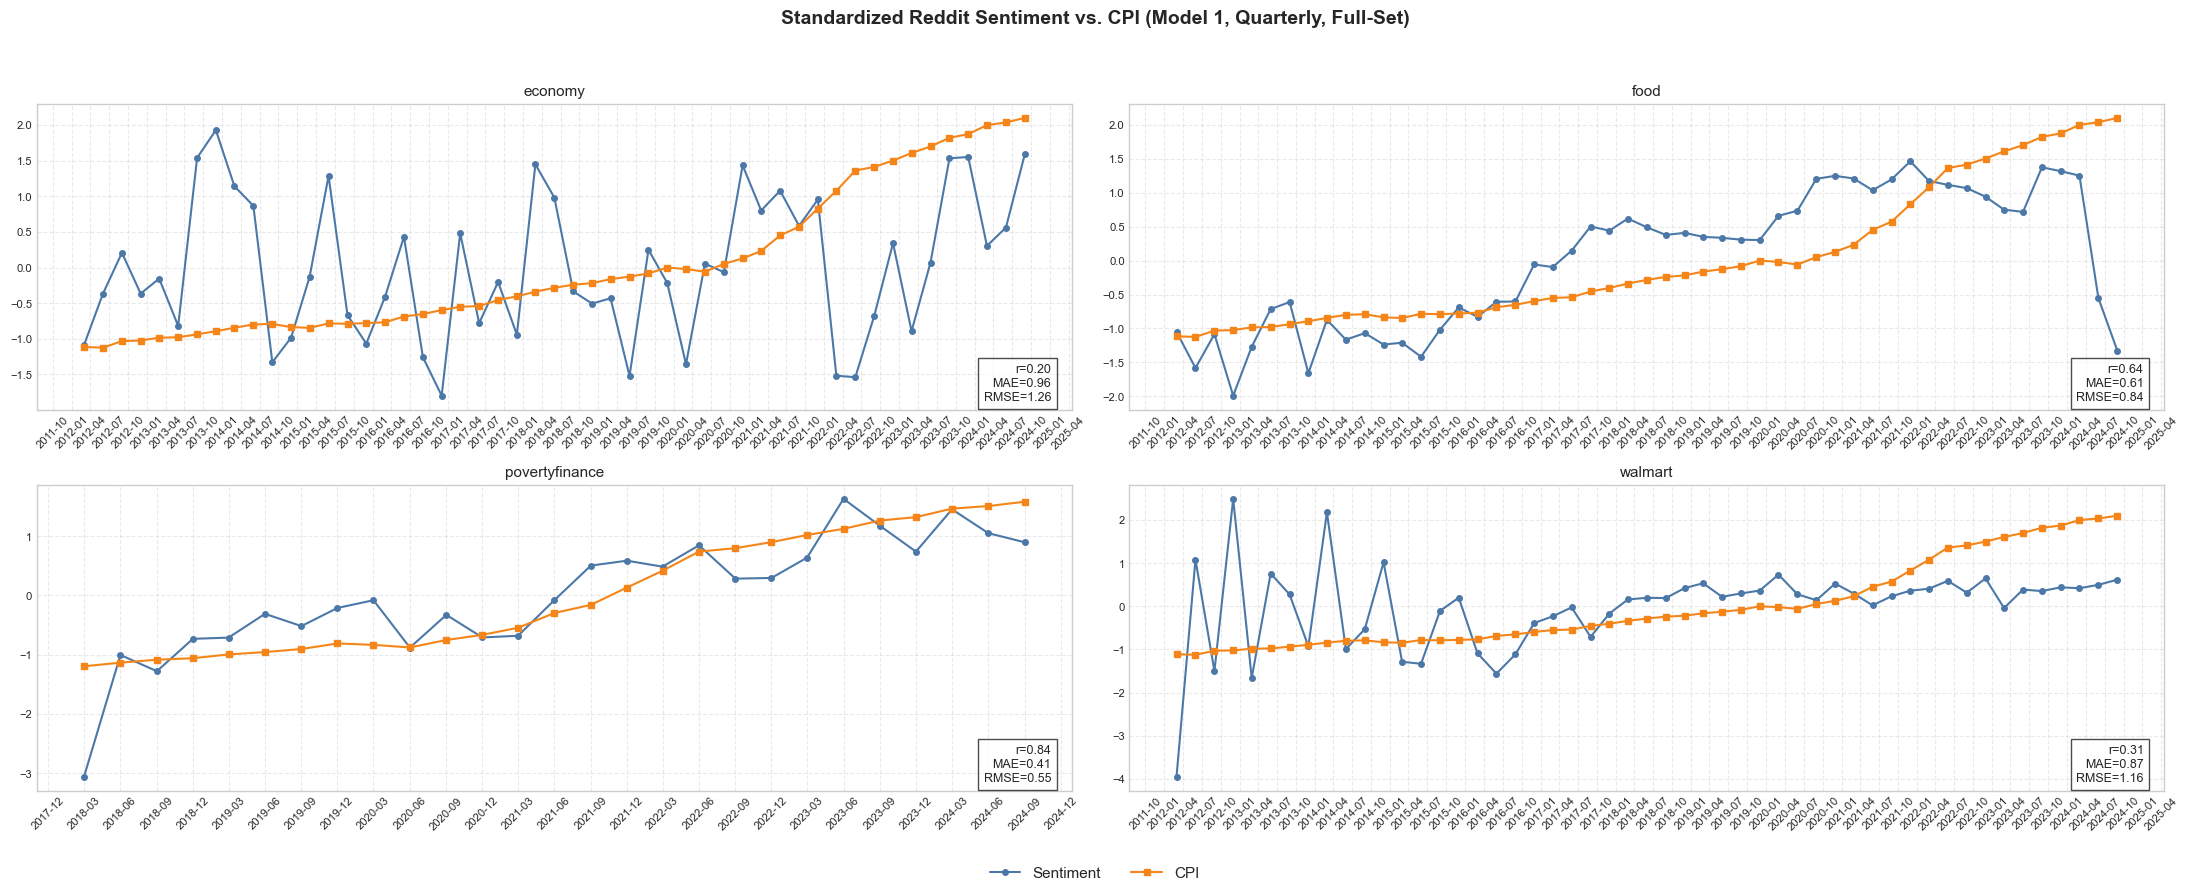

In [24]:
cpi = pd.read_csv("data/inflation/usa_inflation.csv", parse_dates=["date"])

cpi["date"] = cpi["date"].dt.to_period("M").dt.start_time

cpi_q = cpi[cpi["date"].dt.month.isin([3, 6, 9, 12])].copy()

fig, axes = plt.subplots(2, 2, figsize=(22, 9))
axes = axes.flatten()

# Iterate over sentiment files
for i, file in enumerate(sorted(glob("data/output/model_1_vader/full_set/vader_full_*.csv"))):
    name = os.path.basename(file).replace("vader_full_", "").replace(".csv", "")
    sentiment = pd.read_csv(file, parse_dates=["date"])
    sentiment["date"] = sentiment["date"].dt.to_period("M").dt.start_time
    
    df = pd.merge(sentiment, cpi_q, on="date", how="inner").sort_values("date")
    df = pd.merge(sentiment, cpi_q, on="date", how="inner").sort_values("date")

    df["sentiment_z"] = (df["avg_sentiment"] - df["avg_sentiment"].mean()) / df["avg_sentiment"].std()
    df["cpi_z"] = (df["cpi_value"] - df["cpi_value"].mean()) / df["cpi_value"].std()

    r, _ = pearsonr(df["sentiment_z"], df["cpi_z"])
    if r < 0:
        df["sentiment_z"] = -df["sentiment_z"]
        r, _ = pearsonr(df["sentiment_z"], df["cpi_z"])

    mae = mean_absolute_error(df["cpi_z"], df["sentiment_z"])
    rmse = np.sqrt(mean_squared_error(df["cpi_z"], df["sentiment_z"]))

    ax = axes[i]

    ax.plot(df["date"], df["sentiment_z"], label="Sentiment", 
            color=sentiment_color, marker="o", markersize=4, markevery=1, linewidth=1.5)
    ax.plot(df["date"], df["cpi_z"], label="CPI", 
            color=cpi_color, marker="s", markersize=4, markevery=1, linewidth=1.5)
    
    ax.set_title(name, fontsize=11)
    ax.text(0.98, 0.02, f"r={r:.2f}\nMAE={mae:.2f}\nRMSE={rmse:.2f}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=9, bbox=dict(facecolor="white", alpha=0.7))
    ax.tick_params(labelsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)
    
    # Date formatting
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)

# Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=11)

fig.suptitle("Standardized Reddit Sentiment vs. CPI (Model 1, Quarterly, Full-Set)", 
             fontsize=14, weight="bold")

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig("sentiment_vs_cpi_quarters.pdf")
plt.show()

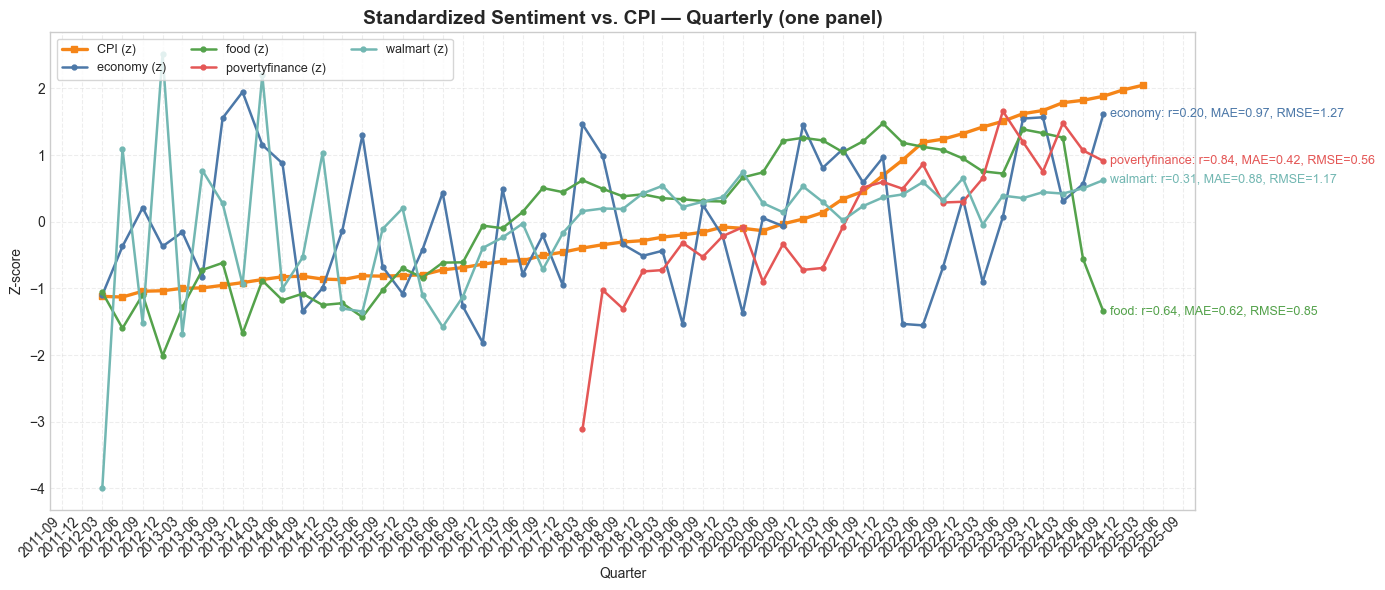


== Metrics (quarterly, z-standardized on overlap) ==
economy           r=0.20  MAE=0.97  RMSE=1.27
food              r=0.64  MAE=0.62  RMSE=0.85
povertyfinance    r=0.84  MAE=0.42  RMSE=0.56
walmart           r=0.31  MAE=0.88  RMSE=1.17


In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")

SENTIMENT_GLOB = "data/output/model_1_vader/full_set/vader_full_*.csv"
SUBREDDITS = ["economy", "food", "povertyfinance", "walmart"]
colors = {
    "economy": "#4C78A8",
    "food": "#54A24B",
    "povertyfinance": "#E45756",
    "walmart": "#72B7B2",
}
cpi_color = "#F58518"

all_dates = []
for f in glob(SENTIMENT_GLOB):
    sent = pd.read_csv(f, parse_dates=["date"])
    sent["date"] = sent["date"].dt.to_period("M").dt.start_time
    if not sent.empty:
        all_dates.append(sent["date"].min())

if not all_dates:
    raise ValueError("Keine Subreddit-Daten gefunden!")

start_date = min(all_dates)

cpi = pd.read_csv("data/inflation/usa_inflation.csv", parse_dates=["date"])
cpi["date"] = cpi["date"].dt.to_period("M").dt.start_time
cpi_q = cpi[cpi["date"].dt.month.isin([3, 6, 9, 12])].copy()

cpi_q = cpi_q[cpi_q["date"] >= start_date].sort_values("date").reset_index(drop=True)

cpi_q["cpi_z_plot"] = (cpi_q["cpi_value"] - cpi_q["cpi_value"].mean()) / cpi_q["cpi_value"].std()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    cpi_q["date"], cpi_q["cpi_z_plot"],
    color=cpi_color, linewidth=2.4, marker="s", markersize=4,
    label="CPI (z)"
)

rows = []
# Iterate over subreddits
for sub in SUBREDDITS:
    candidates = [p for p in glob(SENTIMENT_GLOB) if os.path.basename(p).startswith(f"vader_full_{sub}")]
    if not candidates:
        continue
    f = candidates[0]

    sent = pd.read_csv(f, parse_dates=["date"])
    sent["date"] = sent["date"].dt.to_period("M").dt.start_time
    sent = sent.sort_values("date")

    df = pd.merge(sent, cpi_q[["date", "cpi_value"]], on="date", how="inner")

    if df.empty:
        continue

    s = df["avg_sentiment"].to_numpy()
    c = df["cpi_value"].to_numpy()

    s_z = (s - s.mean()) / s.std()
    c_z = (c - c.mean()) / c.std()

    # Align direction
    r, _ = pearsonr(s_z, c_z)
    if r < 0:
        s_z = -s_z
        r, _ = pearsonr(s_z, c_z)

    mae = mean_absolute_error(c_z, s_z)
    rmse = np.sqrt(mean_squared_error(c_z, s_z))

    # Plot
    df["sentiment_z"] = s_z
    ax.plot(
        df["date"], df["sentiment_z"],
        color=colors.get(sub, "#666"), linewidth=1.8, marker="o", markersize=3.5,
        label=f"{sub} (z)"
    )

    # Annotation
    x_ann = df["date"].iloc[-1]
    y_ann = df["sentiment_z"].iloc[-1]
    ax.text(
        x_ann, y_ann,
        f"  {sub}: r={r:.2f}, MAE={mae:.2f}, RMSE={rmse:.2f}",
        color=colors.get(sub, "#666"), fontsize=9, va="center"
    )

    rows.append((sub, r, mae, rmse))

ax.set_title("Standardized Sentiment vs. CPI — Quarterly (one panel)", fontsize=14, weight="bold")
ax.set_xlabel("Quarter")
ax.set_ylabel("Z-score")
ax.grid(True, linestyle="--", alpha=0.35)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.legend(ncol=3, fontsize=9, loc="upper left", frameon=True)

plt.tight_layout()
plt.savefig("sentiment_vs_cpi_quarter_onepanel.pdf")
plt.show()

# Print metrics
if rows:
    print("\n== Metrics (quarterly, z-standardized on overlap) ==")
    for sub, r, mae, rmse in rows:
        print(f"{sub:16s}  r={r:.2f}  MAE={mae:.2f}  RMSE={rmse:.2f}")

### 2.3.2 Semianual

/Users/christianleis/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/christianleis/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/christianleis/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/christianleis/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will b

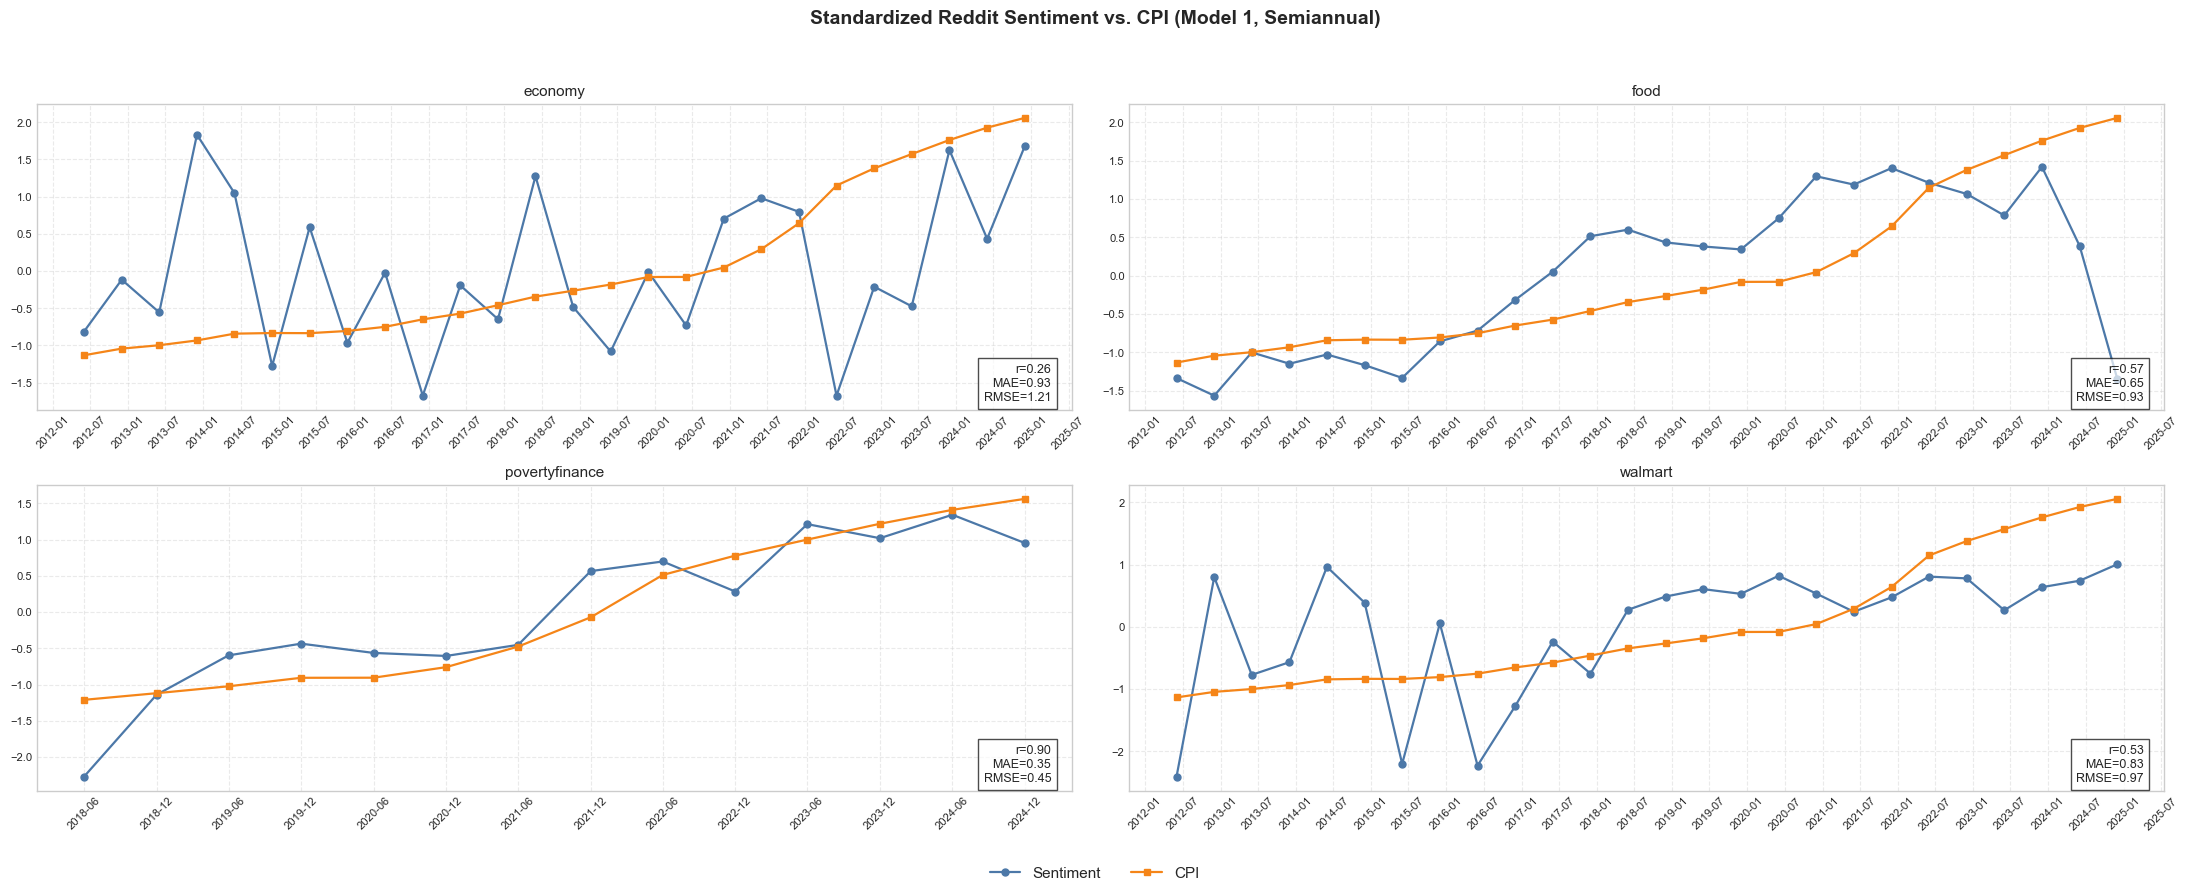

In [25]:
plt.style.use("seaborn-v0_8-whitegrid")

sentiment_color = "#4C78A8"
cpi_color = "#F58518"

# Convert to month start
def to_month_start(s: pd.Series) -> pd.Series:
    return s.dt.to_period("M").dt.start_time

# Convert to semiannual (average of Mar+Jun and Sep+Dec)
def to_semiannual(df: pd.DataFrame, date_col: str, value_col: str) -> pd.DataFrame:
    out = df.copy()
    out[date_col] = to_month_start(out[date_col])
    out["year"] = out[date_col].dt.year
    out["half"] = np.where(out[date_col].dt.month.isin([3,6]), "H1", "H2")
    agg = (
        out[out[date_col].dt.month.isin([3,6,9,12])]
        .groupby(["year","half"], as_index=False)[value_col]
        .mean()
    )

    agg["date"] = pd.to_datetime(
        np.where(agg["half"]=="H1",
                 agg["year"].astype(str)+"-06-01",
                 agg["year"].astype(str)+"-12-01")
    )
    return agg[["date", value_col]]


cpi = pd.read_csv("data/inflation/usa_inflation.csv", parse_dates=["date"])
cpi_h = to_semiannual(cpi, "date", "cpi_value").sort_values("date")

fig, axes = plt.subplots(2, 2, figsize=(22, 9))
axes = axes.flatten()

# Iterate over sentiment files
for i, file in enumerate(sorted(glob("data/output/model_1_vader/full_set/vader_full_*.csv"))):
    name = os.path.basename(file).replace("vader_full_", "").replace(".csv", "")

    sentiment = pd.read_csv(file, parse_dates=["date"])
    sent_h = to_semiannual(sentiment, "date", "avg_sentiment").sort_values("date")

    df = pd.merge(sent_h, cpi_h, on="date", how="inner").sort_values("date")

    df["sentiment_z"] = (df["avg_sentiment"] - df["avg_sentiment"].mean()) / df["avg_sentiment"].std(ddof=0)
    df["cpi_z"] = (df["cpi_value"] - df["cpi_value"].mean()) / df["cpi_value"].std(ddof=0)

    r, _ = pearsonr(df["sentiment_z"], df["cpi_z"])
    if r < 0:
        df["sentiment_z"] = -df["sentiment_z"]
        r, _ = pearsonr(df["sentiment_z"], df["cpi_z"])

    mae = mean_absolute_error(df["cpi_z"], df["sentiment_z"])
    rmse = mean_squared_error(df["cpi_z"], df["sentiment_z"], squared=False)

    ax = axes[i]
    ax.plot(df["date"], df["sentiment_z"], label="Sentiment",
            color=sentiment_color, marker="o", markersize=5, markevery=1, linewidth=1.6)
    ax.plot(df["date"], df["cpi_z"], label="CPI",
            color=cpi_color, marker="s", markersize=5, markevery=1, linewidth=1.6)

    ax.set_title(name, fontsize=11)
    ax.text(0.98, 0.02, f"r={r:.2f}\nMAE={mae:.2f}\nRMSE={rmse:.2f}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=9, bbox=dict(facecolor="white", alpha=0.7))

    ax.tick_params(labelsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)

# Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=11)

fig.suptitle("Standardized Reddit Sentiment vs. CPI (Model 1, Semiannual)",
             fontsize=14, weight="bold")

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig("sentiment_vs_cpi_semiannual.png")
plt.show()

### 2.3.3 Anual

/Users/christianleis/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/christianleis/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/christianleis/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/christianleis/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will b

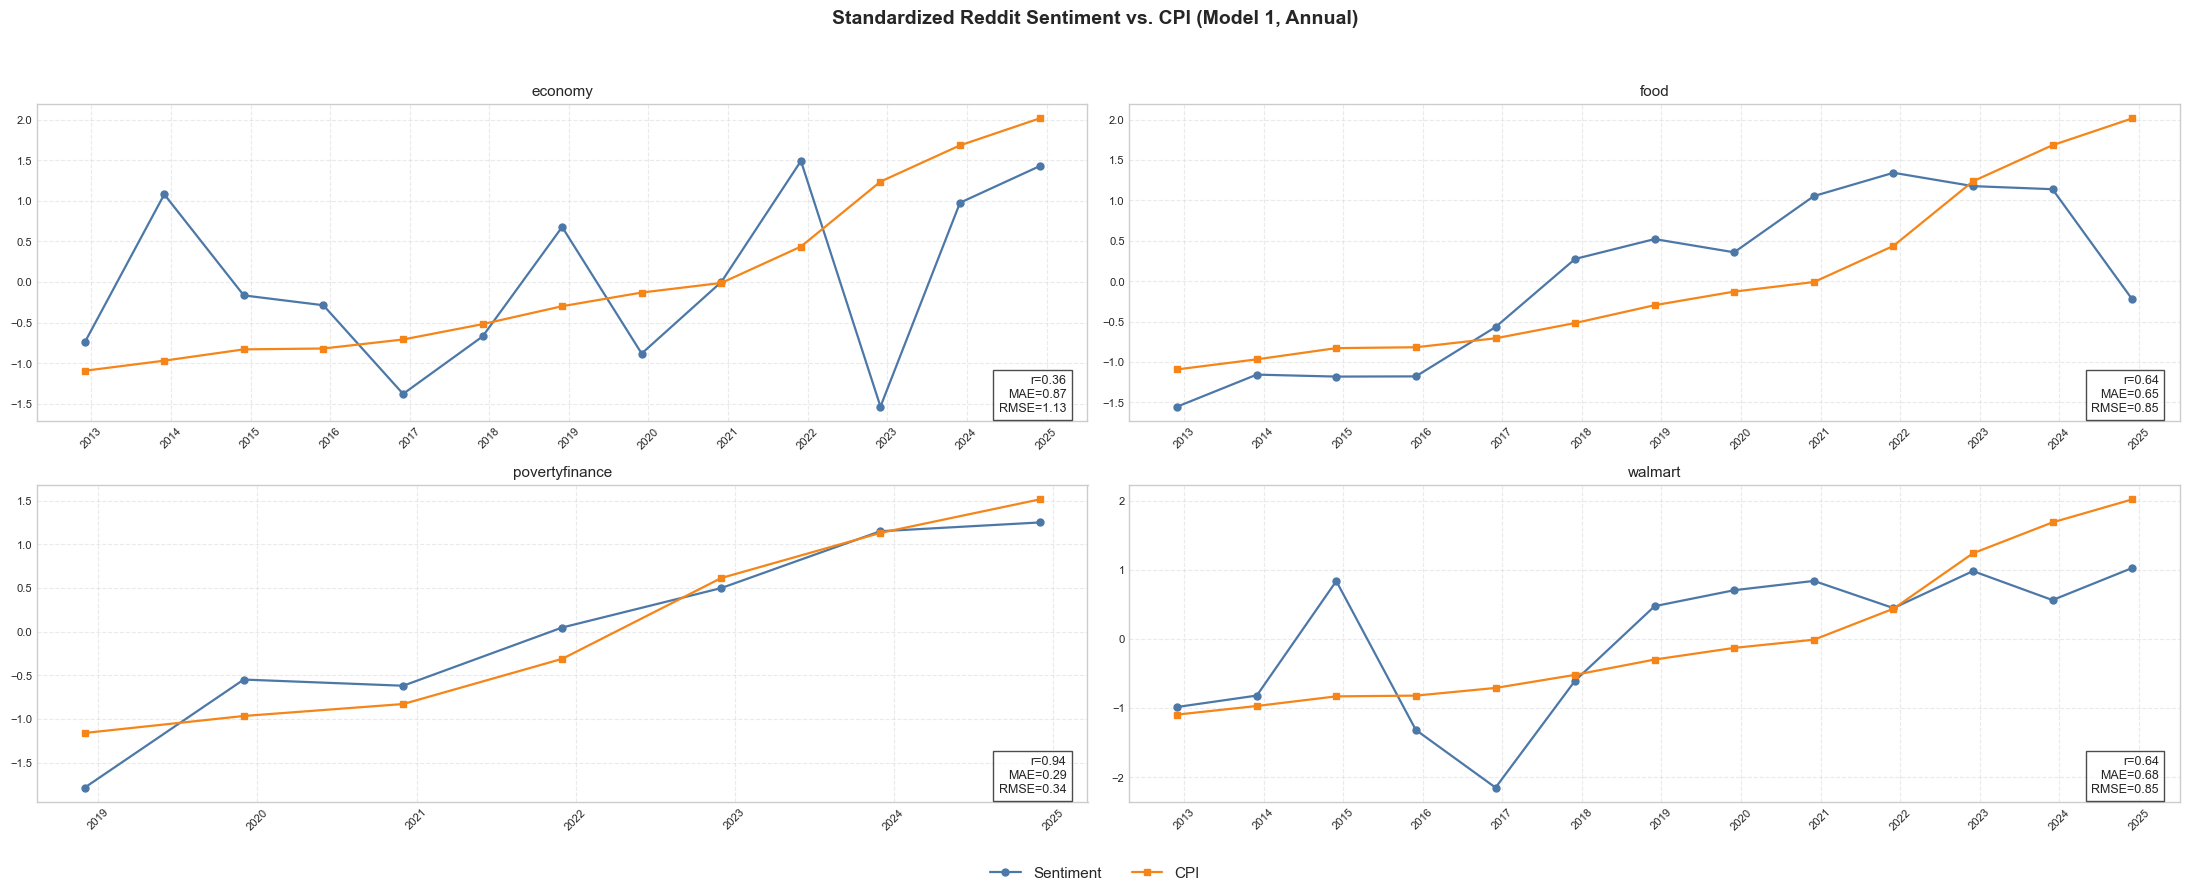

In [26]:
# Convert to annual (average of all months)
def to_annual(df: pd.DataFrame, date_col: str, value_col: str) -> pd.DataFrame:
    out = df.copy()
    out[date_col] = to_month_start(out[date_col])
    out["year"] = out[date_col].dt.year
    agg = out.groupby("year", as_index=False)[value_col].mean()

    agg["date"] = pd.to_datetime(agg["year"].astype(str) + "-12-01")
    return agg[["date", value_col]]

cpi = pd.read_csv("data/inflation/usa_inflation.csv", parse_dates=["date"])
cpi_y = to_annual(cpi, "date", "cpi_value").sort_values("date")

fig, axes = plt.subplots(2, 2, figsize=(22, 9))
axes = axes.flatten()

# Iterate over sentiment files
for i, file in enumerate(sorted(glob("data/output/model_1_vader/full_set/vader_full_*.csv"))):
    name = os.path.basename(file).replace("vader_full_", "").replace(".csv", "")

    sentiment = pd.read_csv(file, parse_dates=["date"])
    sent_y = to_annual(sentiment, "date", "avg_sentiment").sort_values("date")

    df = pd.merge(sent_y, cpi_y, on="date", how="inner").sort_values("date")

    df["sentiment_z"] = (df["avg_sentiment"] - df["avg_sentiment"].mean()) / df["avg_sentiment"].std(ddof=0)
    df["cpi_z"] = (df["cpi_value"] - df["cpi_value"].mean()) / df["cpi_value"].std(ddof=0)

    r, _ = pearsonr(df["sentiment_z"], df["cpi_z"])
    if r < 0:
        df["sentiment_z"] = -df["sentiment_z"]
        r, _ = pearsonr(df["sentiment_z"], df["cpi_z"])

    mae = mean_absolute_error(df["cpi_z"], df["sentiment_z"])
    rmse = mean_squared_error(df["cpi_z"], df["sentiment_z"], squared=False)

    ax = axes[i]
    ax.plot(df["date"], df["sentiment_z"], label="Sentiment",
            color=sentiment_color, marker="o", markersize=5, markevery=1, linewidth=1.6)
    ax.plot(df["date"], df["cpi_z"], label="CPI",
            color=cpi_color, marker="s", markersize=5, markevery=1, linewidth=1.6)

    ax.set_title(name, fontsize=11)
    ax.text(0.98, 0.02, f"r={r:.2f}\nMAE={mae:.2f}\nRMSE={rmse:.2f}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=9, bbox=dict(facecolor="white", alpha=0.7))

    ax.tick_params(labelsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=45)

# Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=11)

fig.suptitle("Standardized Reddit Sentiment vs. CPI (Model 1, Annual)",
             fontsize=14, weight="bold")

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig("sentiment_vs_cpi_annual.png")
plt.show()


## Model 2

/Users/christianleis/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/christianleis/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


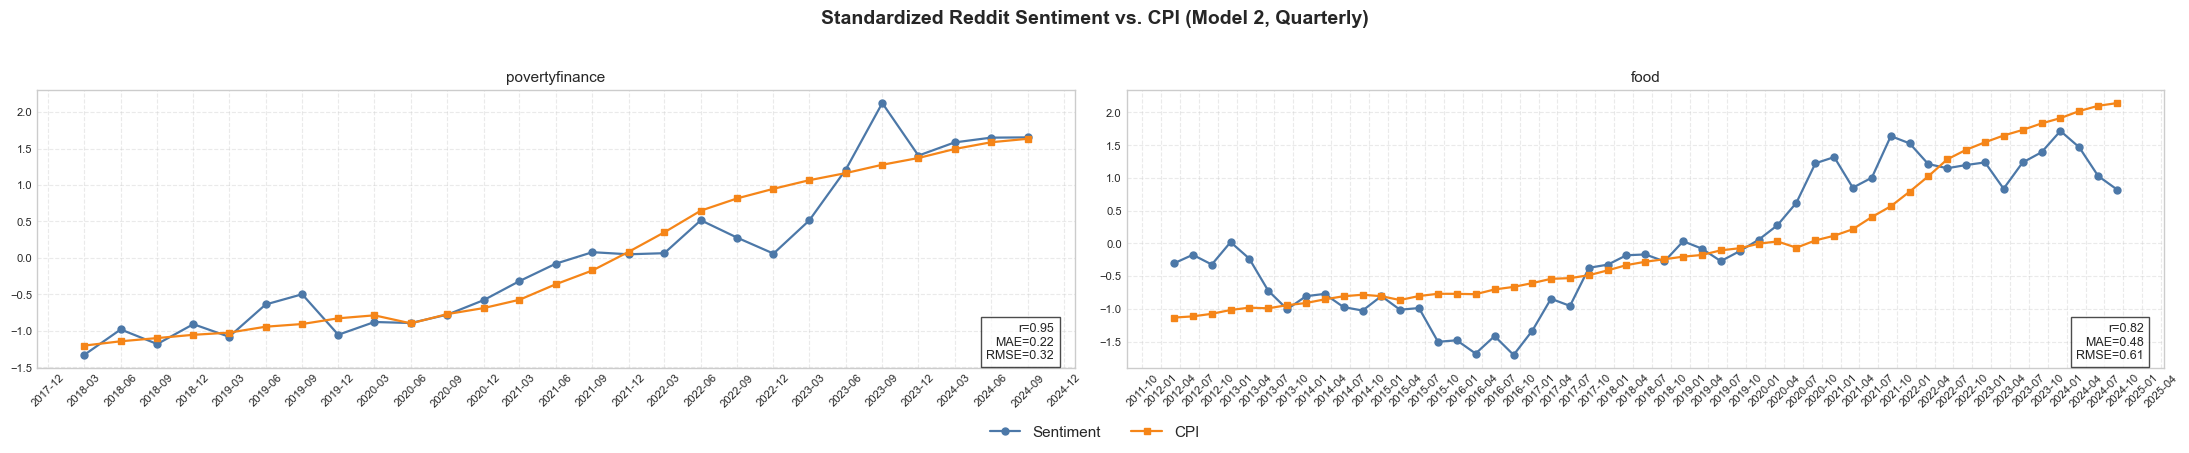

/Users/christianleis/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/christianleis/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


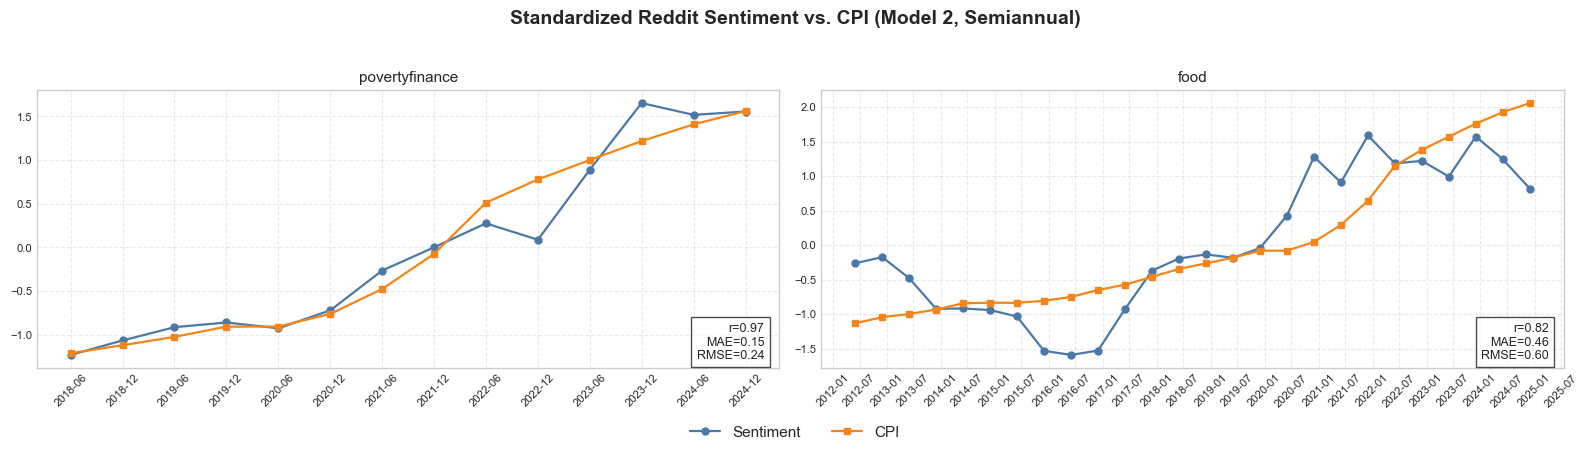

/Users/christianleis/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/christianleis/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


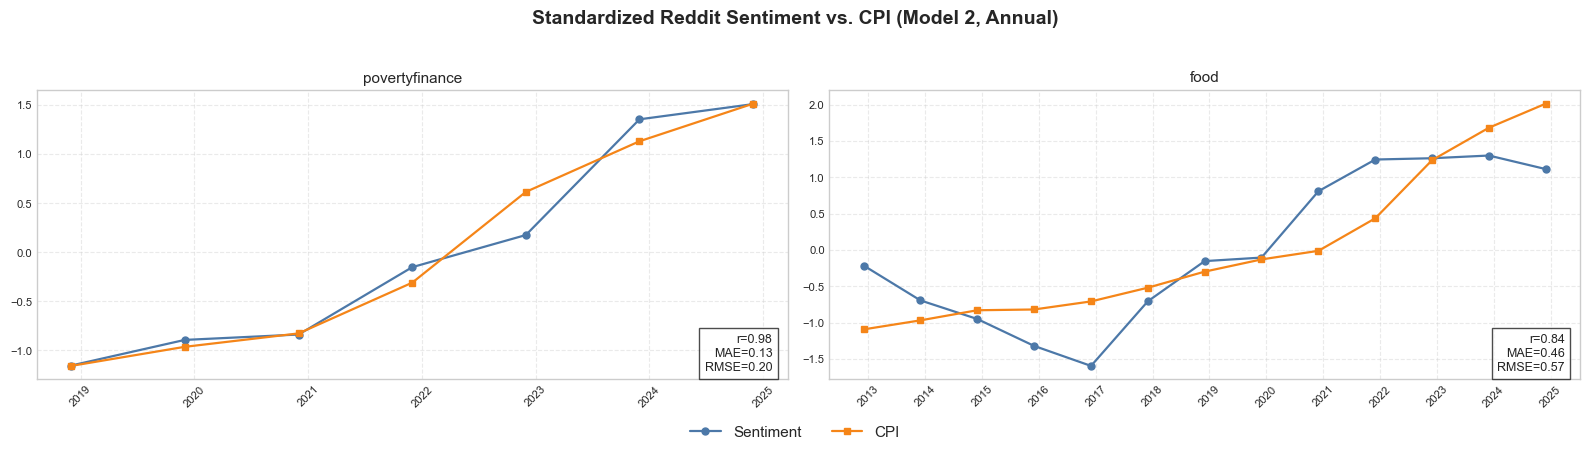

In [42]:
plt.style.use("seaborn-v0_8-whitegrid")
sentiment_color = "#4C78A8"
cpi_color = "#F58518"

# Convert to month start
def to_month_start(s: pd.Series) -> pd.Series:
    return s.dt.to_period("M").dt.start_time

# Weighted group mean
def weighted_group_mean(df: pd.DataFrame, val_col: str, w_col: str | None) -> float:
    if w_col is None or df[w_col].isna().all():
        return df[val_col].mean()
    w = df[w_col].fillna(0)
    if w.sum() == 0:
        return np.nan
    return np.average(df[val_col], weights=w)

# Convert to quarterly (average of Mar, Jun, Sep, Dec)
def make_quarterly(df: pd.DataFrame, date_col: str, val_col: str, w_col: str | None = None) -> pd.DataFrame:
    x = df.copy()
    x[date_col] = to_month_start(x[date_col])
    x["year"] = x[date_col].dt.year
    x["q"] = x[date_col].dt.quarter
    g = x.groupby(["year","q"], as_index=False).apply(
        lambda g: pd.Series({val_col: weighted_group_mean(g, val_col, w_col)})
    ).reset_index(drop=True)
    qend_month = {1:"03", 2:"06", 3:"09", 4:"12"}
    g["date"] = pd.to_datetime(g["year"].astype(str) + "-" + g["q"].map(qend_month) + "-01")
    return g[["date", val_col]].sort_values("date")

#  Weighted group mean
def make_semiannual(df: pd.DataFrame, date_col: str, val_col: str, w_col: str | None = None) -> pd.DataFrame:
    x = df.copy()
    x[date_col] = to_month_start(x[date_col])
    x = x[x[date_col].dt.month.isin([3,6,9,12])]
    x["year"] = x[date_col].dt.year
    x["half"] = np.where(x[date_col].dt.month.isin([3,6]), "H1", "H2")
    g = x.groupby(["year","half"], as_index=False).apply(
        lambda g: pd.Series({val_col: weighted_group_mean(g, val_col, w_col)})
    ).reset_index(drop=True)
    g["date"] = pd.to_datetime(np.where(
        g["half"]=="H1",
        g["year"].astype(str)+"-06-01",
        g["year"].astype(str)+"-12-01"
    ))
    return g[["date", val_col]].sort_values("date")

# Weighted group mean
def make_annual(df: pd.DataFrame, date_col: str, val_col: str, w_col: str | None = None) -> pd.DataFrame:
    x = df.copy()
    x[date_col] = to_month_start(x[date_col])
    x["year"] = x[date_col].dt.year
    g = x.groupby("year", as_index=False).apply(
        lambda g: pd.Series({val_col: weighted_group_mean(g, val_col, w_col)})
    ).reset_index(drop=True)
    g["date"] = pd.to_datetime(g["year"].astype(str) + "-12-01")
    return g[["date", val_col]].sort_values("date")

# Z-transform and invert if needed
def z_and_invert(df: pd.DataFrame) -> tuple[pd.DataFrame, float, float, float]:
    df = df.copy()
    df["sentiment_z"] = (df["avg_sentiment"] - df["avg_sentiment"].mean()) / df["avg_sentiment"].std(ddof=0)
    df["cpi_z"] = (df["cpi_value"] - df["cpi_value"].mean()) / df["cpi_value"].std(ddof=0)
    r, _ = pearsonr(df["sentiment_z"], df["cpi_z"])
    if r < 0:
        df["sentiment_z"] = -df["sentiment_z"]
        r, _ = pearsonr(df["sentiment_z"], df["cpi_z"])
    mae = mean_absolute_error(df["cpi_z"], df["sentiment_z"])
    rmse = mean_squared_error(df["cpi_z"], df["sentiment_z"], squared=False)
    return df, r, mae, rmse

# Plot lines with stats
def plot_lines(ax, df, title, stats):
    r, mae, rmse = stats
    ax.plot(df["date"], df["sentiment_z"], label="Sentiment",
            color=sentiment_color, marker="o", markersize=5, markevery=1, linewidth=1.6)
    ax.plot(df["date"], df["cpi_z"], label="CPI",
            color=cpi_color, marker="s", markersize=5, markevery=1, linewidth=1.6)
    ax.set_title(title, fontsize=11)
    ax.text(0.98, 0.02, f"r={r:.2f}\nMAE={mae:.2f}\nRMSE={rmse:.2f}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=9, bbox=dict(facecolor="white", alpha=0.7))
    ax.tick_params(labelsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)

sentiment_paths = {
    "povertyfinance": "data/output/model_2_bert/full_set/bert_full_1_povertyfinance.csv",
    "food":           "data/output/model_2_bert/full_set/bert_full_1_food.csv",
}

# Load CPI data and prepare different aggregations
cpi = pd.read_csv("data/inflation/usa_inflation.csv", parse_dates=["date"])
cpi["date"] = to_month_start(cpi["date"])
cpi_q = make_quarterly(cpi, "date", "cpi_value")
cpi_h = make_semiannual(cpi, "date", "cpi_value")
cpi_y = make_annual(cpi, "date", "cpi_value")

# 1) Quarterly
fig_q, axes_q = plt.subplots(1, 2, figsize=(22, 4.5))
for ax, (name, path) in zip(axes_q, sentiment_paths.items()):
    sent = pd.read_csv(path, parse_dates=["date"])
    sent["date"] = to_month_start(sent["date"])
    sent_q = make_quarterly(sent, "date", "avg_sentiment", w_col="n_posts")
    df = pd.merge(sent_q, cpi_q, on="date", how="inner").dropna().sort_values("date")
    if len(df) < 3:
        ax.set_title(f"{name} — Quarterly")
        ax.axis("off"); continue
    df_z, r, mae, rmse = z_and_invert(df)
    plot_lines(ax, df_z, f"{name}", (r, mae, rmse))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)
handles, labels = axes_q[0].get_legend_handles_labels()
fig_q.legend(handles, labels, loc="lower center", ncol=2, fontsize=11)
fig_q.suptitle("Standardized Reddit Sentiment vs. CPI (Model 2, Quarterly)", fontsize=14, weight="bold")
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.savefig("combined_vs_cpi_quarterly.png", dpi=180)
plt.show()

# 2) Semiannual
fig_h, axes_h = plt.subplots(1, 2, figsize=(16, 4.5))
for ax, (name, path) in zip(axes_h, sentiment_paths.items()):
    sent = pd.read_csv(path, parse_dates=["date"])
    sent["date"] = to_month_start(sent["date"])
    sent_h = make_semiannual(sent, "date", "avg_sentiment", w_col="n_posts")
    df = pd.merge(sent_h, cpi_h, on="date", how="inner").dropna().sort_values("date")
    if len(df) < 3:
        ax.set_title(f"{name} — Semiannual ")
        ax.axis("off"); continue
    df_z, r, mae, rmse = z_and_invert(df)
    plot_lines(ax, df_z, f"{name}", (r, mae, rmse))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)
handles, labels = axes_h[0].get_legend_handles_labels()
fig_h.legend(handles, labels, loc="lower center", ncol=2, fontsize=11)
fig_h.suptitle("Standardized Reddit Sentiment vs. CPI (Model 2, Semiannual)", fontsize=14, weight="bold")
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.savefig("combined_vs_cpi_semiannual.png", dpi=180)
plt.show()

# 3) Annual
fig_y, axes_y = plt.subplots(1, 2, figsize=(16, 4.5))
for ax, (name, path) in zip(axes_y, sentiment_paths.items()):
    sent = pd.read_csv(path, parse_dates=["date"])
    sent["date"] = to_month_start(sent["date"])
    sent_y = make_annual(sent, "date", "avg_sentiment", w_col="n_posts")
    df = pd.merge(sent_y, cpi_y, on="date", how="inner").dropna().sort_values("date")
    if len(df) < 3:
        ax.set_title(f"{name} — Annual ")
        ax.axis("off"); continue
    df_z, r, mae, rmse = z_and_invert(df)
    plot_lines(ax, df_z, f"{name}", (r, mae, rmse))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=45)
handles, labels = axes_y[0].get_legend_handles_labels()
fig_y.legend(handles, labels, loc="lower center", ncol=2, fontsize=11)
fig_y.suptitle("Standardized Reddit Sentiment vs. CPI (Model 2, Annual)", fontsize=14, weight="bold")
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.savefig("combined_vs_cpi_annual.png", dpi=180)
plt.show()


### Model 3

/Users/christianleis/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/christianleis/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


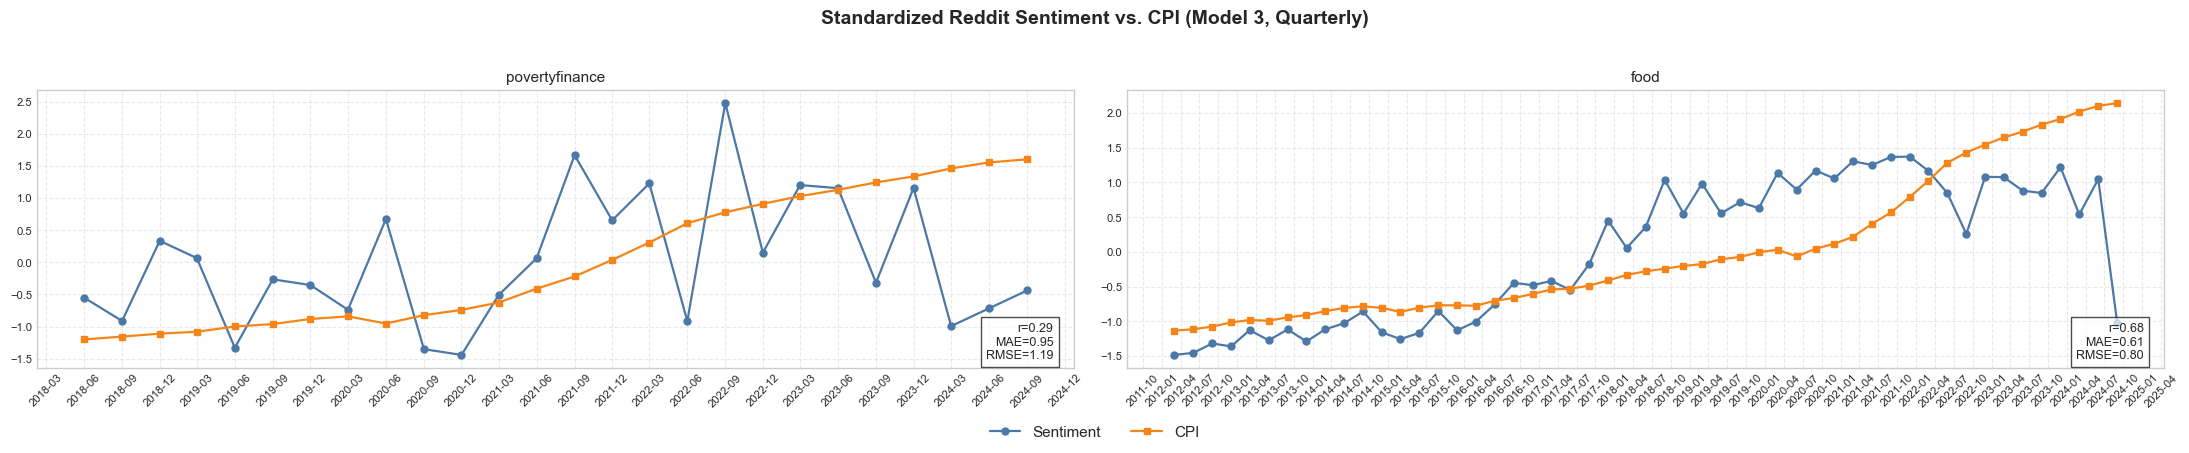

/Users/christianleis/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/christianleis/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


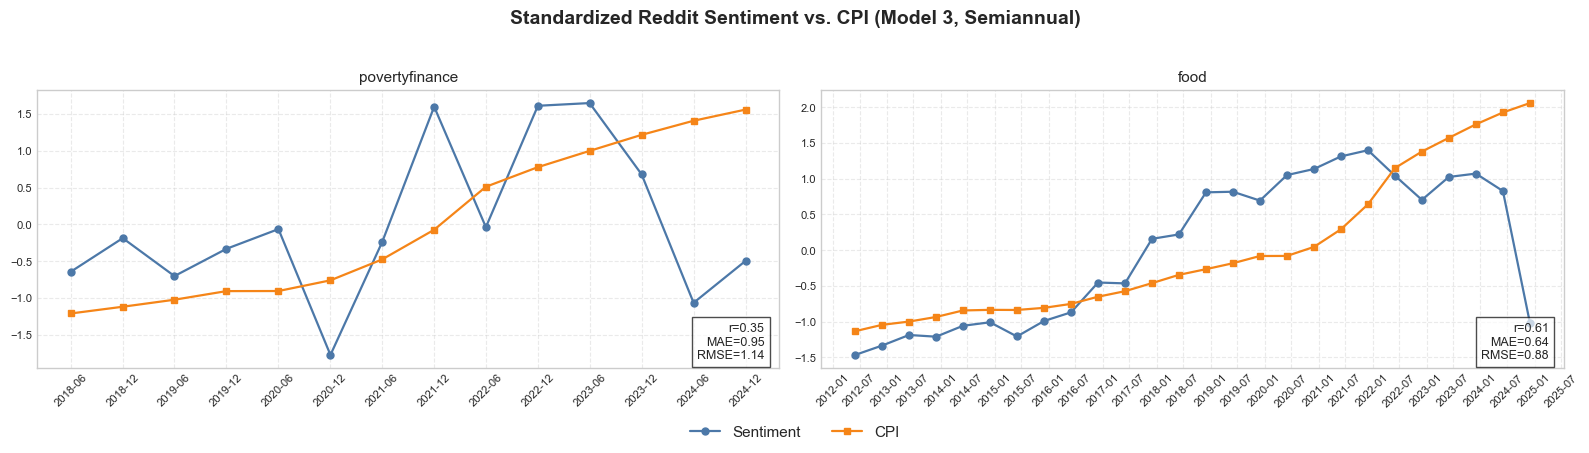

/Users/christianleis/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/christianleis/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


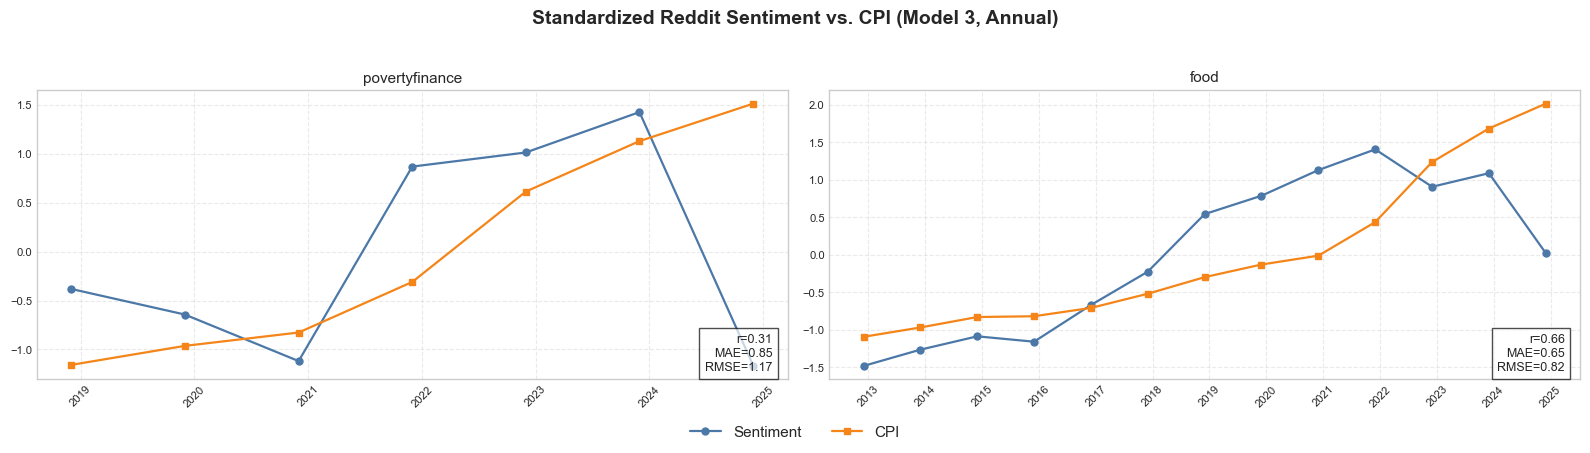

In [41]:

sentiment_paths = {
    "povertyfinance": "data/output/model_3_bert/full_set/bert_full_2_povertyfinance.csv",
    "food":           "data/output/model_3_bert/full_set/bert_full_2_food.csv",
}

# CPI + Aggregationen
cpi = pd.read_csv("data/inflation/usa_inflation.csv", parse_dates=["date"])
cpi["date"] = to_month_start(cpi["date"])
cpi_q = make_quarterly(cpi, "date", "cpi_value")
cpi_h = make_semiannual(cpi, "date", "cpi_value")
cpi_y = make_annual(cpi, "date", "cpi_value")

# 1) Quarterly
fig_q, axes_q = plt.subplots(1, 2, figsize=(22, 4.5))
for ax, (name, path) in zip(axes_q, sentiment_paths.items()):
    sent = pd.read_csv(path, parse_dates=["date"])
    sent["date"] = to_month_start(sent["date"])
    sent_q = make_quarterly(sent, "date", "avg_sentiment", w_col="n_posts")
    df = pd.merge(sent_q, cpi_q, on="date", how="inner").dropna().sort_values("date")
    if len(df) < 3:
        ax.set_title(f"{name} — Quarterly ")
        ax.axis("off"); continue
    df_z, r, mae, rmse = z_and_invert(df)
    plot_lines(ax, df_z, f"{name}", (r, mae, rmse))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)
handles, labels = axes_q[0].get_legend_handles_labels()
fig_q.legend(handles, labels, loc="lower center", ncol=2, fontsize=11)
fig_q.suptitle("Standardized Reddit Sentiment vs. CPI (Model 3, Quarterly)", fontsize=14, weight="bold")
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.savefig("combined_vs_cpi_quarterly.png", dpi=180)
plt.show()

# 2) Semiannual
fig_h, axes_h = plt.subplots(1, 2, figsize=(16, 4.5))
for ax, (name, path) in zip(axes_h, sentiment_paths.items()):
    sent = pd.read_csv(path, parse_dates=["date"])
    sent["date"] = to_month_start(sent["date"])
    sent_h = make_semiannual(sent, "date", "avg_sentiment", w_col="n_posts")
    df = pd.merge(sent_h, cpi_h, on="date", how="inner").dropna().sort_values("date")
    if len(df) < 3:
        ax.set_title(f"{name} — Semiannual")
        ax.axis("off"); continue
    df_z, r, mae, rmse = z_and_invert(df)
    plot_lines(ax, df_z, f"{name}", (r, mae, rmse))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)
handles, labels = axes_h[0].get_legend_handles_labels()
fig_h.legend(handles, labels, loc="lower center", ncol=2, fontsize=11)
fig_h.suptitle("Standardized Reddit Sentiment vs. CPI (Model 3, Semiannual)", fontsize=14, weight="bold")
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.savefig("combined_vs_cpi_semiannual.png", dpi=180)
plt.show()

# 3) Annual
fig_y, axes_y = plt.subplots(1, 2, figsize=(16, 4.5))
for ax, (name, path) in zip(axes_y, sentiment_paths.items()):
    sent = pd.read_csv(path, parse_dates=["date"])
    sent["date"] = to_month_start(sent["date"])
    sent_y = make_annual(sent, "date", "avg_sentiment", w_col="n_posts")
    df = pd.merge(sent_y, cpi_y, on="date", how="inner").dropna().sort_values("date")
    if len(df) < 3:
        ax.set_title(f"{name}")
        ax.axis("off"); continue
    df_z, r, mae, rmse = z_and_invert(df)
    plot_lines(ax, df_z, f"{name}", (r, mae, rmse))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=45)
handles, labels = axes_y[0].get_legend_handles_labels()
fig_y.legend(handles, labels, loc="lower center", ncol=2, fontsize=11)
fig_y.suptitle("Standardized Reddit Sentiment vs. CPI (Model 3, Annual)", fontsize=14, weight="bold")
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.savefig("combined_vs_cpi_annual.png", dpi=180)
plt.show()
